In [78]:
import numpy as np
import cv2
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from skimage.draw import polygon
from sklearn.metrics import average_precision_score
from skimage.morphology import skeletonize

In [ ]:
PROJECT_ROOT = Path.cwd().parent if (Path.cwd().name == "NoteBooks") else Path.cwd()
PRE_ROOT     = PROJECT_ROOT / "preprocessed" # original preprocessed images
SCALE_ROOTS  = [
    PROJECT_ROOT / "superPixel_graph_sem/scale_K1500_C10",
    PROJECT_ROOT / "superPixel_graph_sem/scale_K3500_C6",
    PROJECT_ROOT / "superPixel_graph_sem/scale_K4500_C5",
]

In [80]:
split = "train"
img_name = "263_D.png"

In [81]:
gray_path = PRE_ROOT / split / "images" / img_name
fov_path  = PRE_ROOT / split / "fov_masks" / img_name

gray_u8 = cv2.imread(str(gray_path), cv2.IMREAD_GRAYSCALE)
fov_u8  = cv2.imread(str(fov_path), cv2.IMREAD_GRAYSCALE)

assert gray_u8 is not None, "Image not found"
assert fov_u8 is not None, "FOV not found"

In [82]:
sem_files = []
for root in SCALE_ROOTS:
    f = root / split / (img_name.replace(".png","") + "_sem.npz")
    sem_files.append(np.load(f, allow_pickle=True))

In [83]:
sem_results = []
for data in sem_files:
    sem_results.append({
        "p"     : data["vessel_prob"],    # (K,)
        "cent"  : data["centroids"],      # (K,2)
        "edges" : data["edges"],          # (2,E)
        "feats" : data["features"],       # (K,4)
        "labels" : data["labels"],        # (H,W)
    })

In [84]:
def render_prob_map(centroids, probs, gray_h, gray_w, fill_sigma=12):
    """
    Convert node-level probabilities to a dense image using Gaussian fill.
    """
    prob_img = np.zeros((gray_h, gray_w), dtype=np.float32)
    weight   = np.zeros((gray_h, gray_w), dtype=np.float32)

    for (cy, cx), p in zip(centroids, probs):
        cy = int(cy)
        cx = int(cx)

        y0, y1 = max(0, cy - fill_sigma), min(gray_h, cy + fill_sigma)
        x0, x1 = max(0, cx - fill_sigma), min(gray_w, cx + fill_sigma)

        yy, xx = np.mgrid[y0:y1, x0:x1]
        g = np.exp(-((yy-cy)**2 + (xx-cx)**2) / (2*(fill_sigma**2)))

        prob_img[y0:y1, x0:x1]  += p * g
        weight[y0:y1, x0:x1]    += g

    prob_img = prob_img / (weight + 1e-6)
    return prob_img

In [85]:
H, W = gray_u8.shape
prob_scales = []

for sem in sem_results:
    p       = sem["p"]        # (K,)
    labels  = sem["labels"]   # (H,W)

    # map node probs to each pixel
    pmap = p[labels]

    # zero outside FOV
    pmap = pmap * (fov_u8 > 0)

    prob_scales.append(pmap.astype(np.float32))

In [86]:
p_avg = np.mean(prob_scales, axis=0)

In [87]:
eps = 1e-6
p_geo = np.exp(np.mean([np.log(p + eps) for p in prob_scales], axis=0))

In [88]:
p_final = p_avg

In [89]:
p_final = p_final * (gray_u8 < 53) #hyper parameter

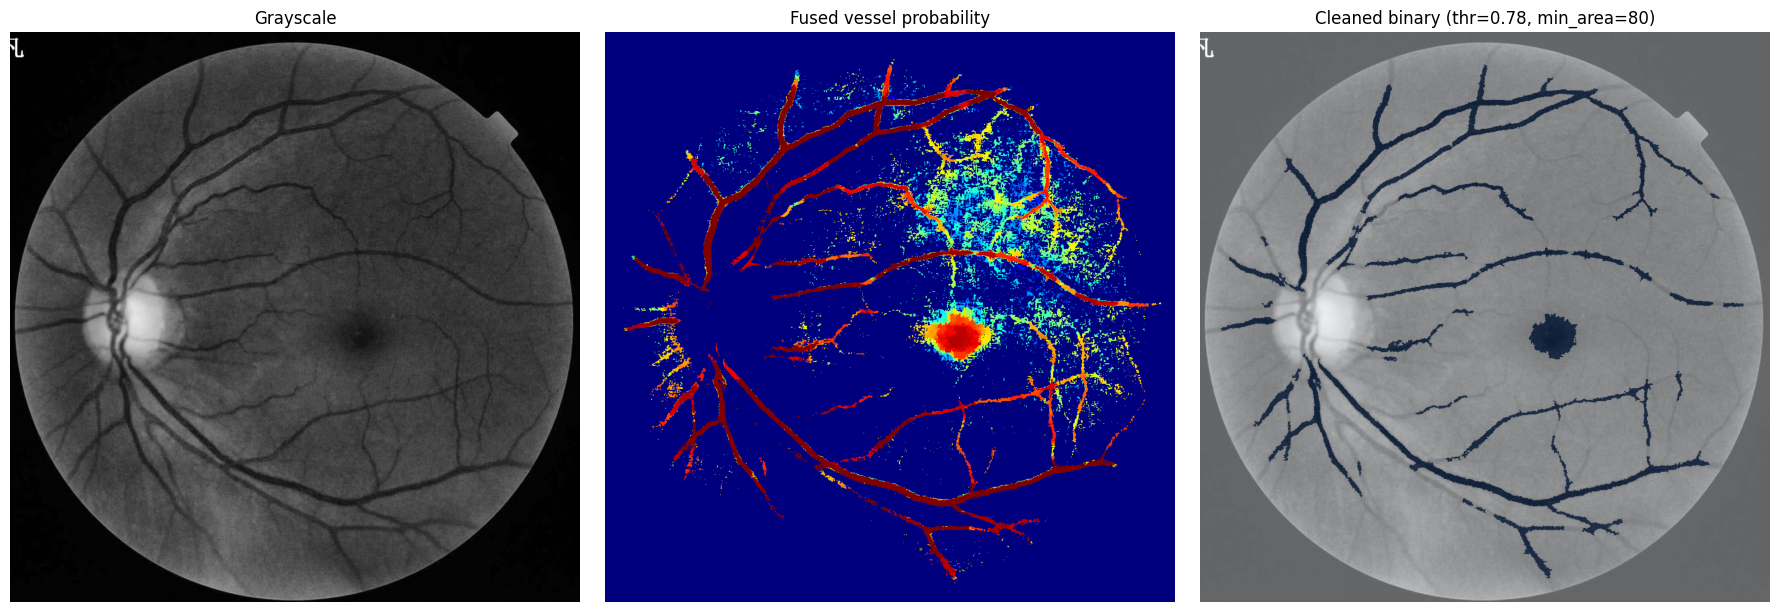

In [90]:
#Threshold to get initial binary mask
thr = 0.78
binary = (p_final >= thr).astype(np.uint8)

#Restrict to FOV
binary = binary * (fov_u8 > 0).astype(np.uint8)

#Remove small connected components
# Convert to 0/255 for OpenCV
binary_u8 = (binary * 255).astype(np.uint8)

# Connected components
num_labels, labels_cc, stats, centroids = cv2.connectedComponentsWithStats(
    binary_u8, connectivity=8
)

# stats[:, cv2.CC_STAT_AREA] gives area of each component
areas = stats[:, cv2.CC_STAT_AREA]

# Minimum area to keep
min_area = 80   # hyper parameter

# Build filtered mask: keep components whose area >= min_area
filtered_mask = np.zeros_like(binary, dtype=np.uint8)
for label in range(1, num_labels):   # 0 = background
    if areas[label] >= min_area:
        filtered_mask[labels_cc == label] = 1

# a small morphological closing to join tiny gaps
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
filtered_mask = cv2.morphologyEx(filtered_mask, cv2.MORPH_CLOSE, kernel)

# Visualize overlay after cleaning
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(gray_u8, cmap='gray')
axes[0].set_title("Grayscale"); axes[0].axis('off')

axes[1].imshow(p_final, cmap='jet')
axes[1].set_title("Fused vessel probability"); axes[1].axis('off')

axes[2].imshow(gray_u8, cmap='gray')
axes[2].imshow(filtered_mask, alpha=0.4, cmap='Blues')
axes[2].set_title(f"Cleaned binary (thr={thr}, min_area={min_area})")
axes[2].axis('off')

plt.tight_layout()
plt.show()


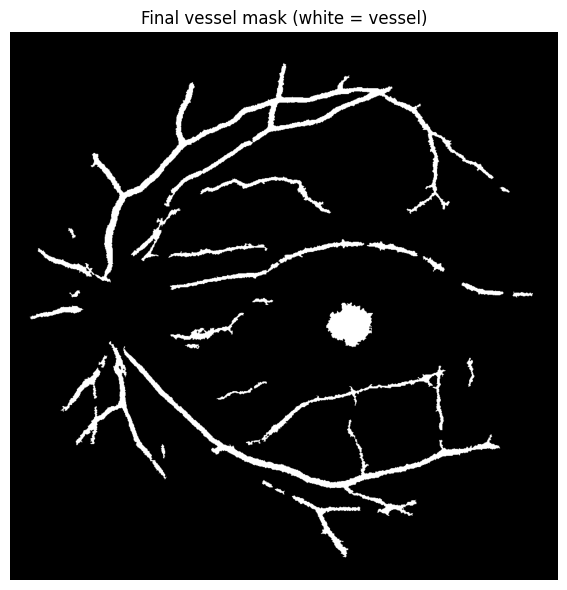

In [91]:
# filtered_mask is 0/1, convert to 0/255 for a white-on-black mask
vessel_mask = (filtered_mask * 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(vessel_mask, cmap='gray', vmin=0, vmax=255)
plt.title("Final vessel mask (white = vessel)")
plt.axis('off')
plt.tight_layout()
plt.show()


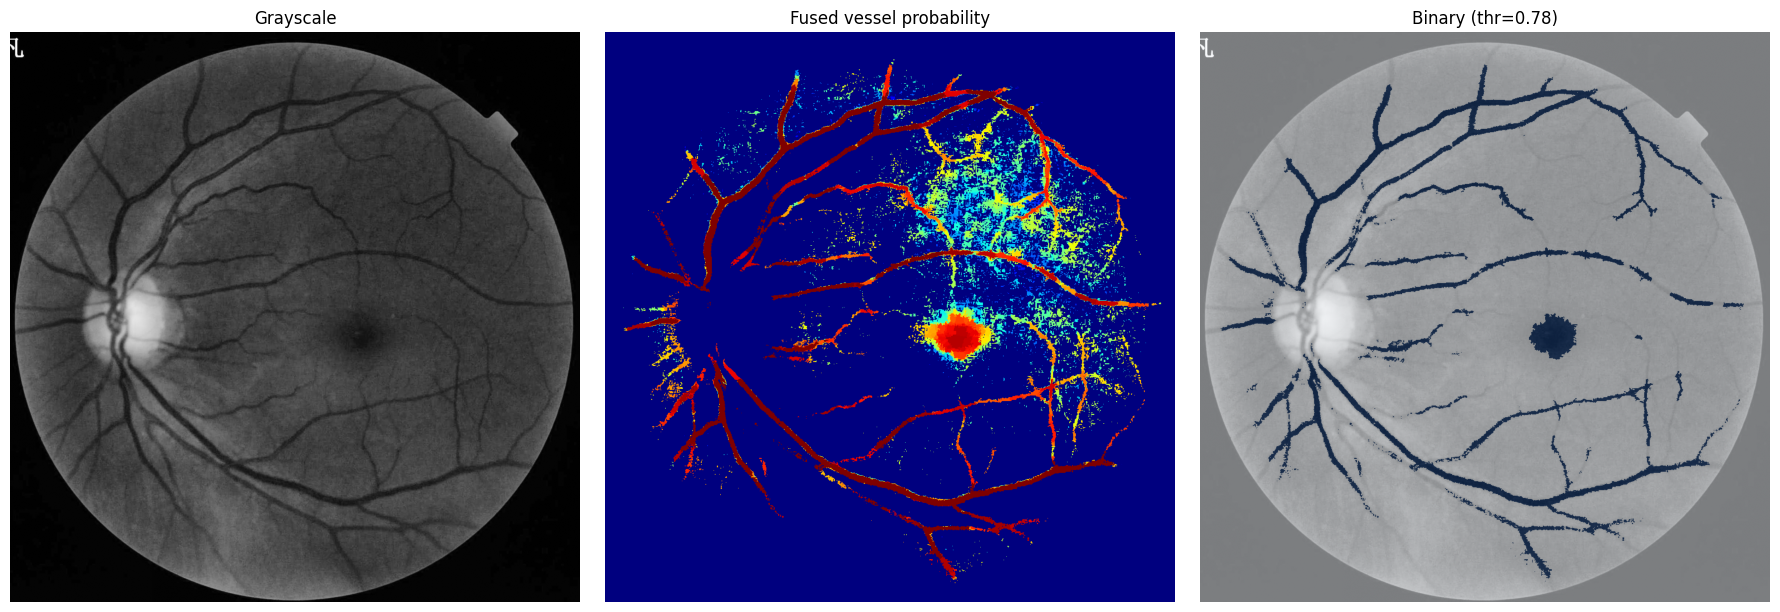

In [92]:
fig, axs = plt.subplots(1, 3, figsize=(18,6))

axs[0].imshow(gray_u8, cmap='gray')
axs[0].set_title("Grayscale")
axs[0].axis('off')

axs[1].imshow(p_final, cmap='jet', vmin=0, vmax=1)
axs[1].set_title("Fused vessel probability")
axs[1].axis('off')

thr = 0.78
mask = (p_final >= thr).astype(np.uint8)

axs[2].imshow(gray_u8, cmap='gray')
axs[2].imshow(mask, cmap='Blues', alpha=0.5)
axs[2].set_title(f"Binary (thr={thr})")
axs[2].axis('off')

plt.tight_layout()
plt.show()


In [93]:
# p_avg = fused vessel probability map (H,W)

split    = split    if 'split' in globals()    else "train"
img_name = img_name if 'img_name' in globals() else "100_A.png"


gt_path = PROJECT_ROOT / "dataset" / split / "Ground truth" / img_name
gt_mask = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
if gt_mask is None:
    raise RuntimeError(f"Could not read GT mask at {gt_path}")

gt_bin = (gt_mask > 0).astype(np.uint8)

h_p, w_p = p_final.shape
if gt_bin.shape != p_final.shape:
    print(f"Resizing GT from {gt_bin.shape} to {p_final.shape} for evaluation")
    gt_bin = cv2.resize(gt_bin, (w_p, h_p), interpolation=cv2.INTER_NEAREST)


thresholds = [0.70, 0.75, 0.77, 0.78, 0.80, 0.90, 0.95]

#PR-AUC (Precision–Recall AUC, threshold-free)
y_true  = gt_bin.ravel().astype(np.uint8)
y_score = p_final.ravel().astype(np.float32)
pr_auc  = average_precision_score(y_true, y_score)

#clDice
def cldice_score(pred_bin: np.ndarray, gt_bin: np.ndarray, eps: float = 1e-6) -> float:
    pred = pred_bin.astype(bool)
    gt   = gt_bin.astype(bool)
    if pred.sum() == 0 or gt.sum() == 0:
        return 0.0

    skel_pred = skeletonize(pred)
    skel_gt   = skeletonize(gt)

    t_prec = (skel_pred & gt).sum() / (skel_pred.sum() + eps)
    t_sens = (skel_gt & pred).sum() / (skel_gt.sum() + eps)

    return 2.0 * t_prec * t_sens / (t_prec + t_sens + eps)

#Loop over thresholds and compute metrics
rows = []

for thr in thresholds:
    pred_bin = (p_final >= thr).astype(np.uint8)

    tp = int(((pred_bin == 1) & (gt_bin == 1)).sum())
    fp = int(((pred_bin == 1) & (gt_bin == 0)).sum())
    fn = int(((pred_bin == 0) & (gt_bin == 1)).sum())

    dice = 2.0 * tp / (2.0 * tp + fp + fn + 1e-6)
    cld  = cldice_score(pred_bin, gt_bin)

    rows.append({
        "threshold": thr,
        "Dice":      dice,
        "clDice":    cld,
        "PR-AUC":    pr_auc,   # same for all thresholds
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)


Resizing GT from (2048, 2048) to (1024, 1024) for evaluation


,threshold,Dice,clDice,PR-AUC
0,0.70,0.670118,0.681992,0.613758
1,0.75,0.655724,0.661735,0.613758
2,0.77,0.650191,0.652730,0.613758
3,0.78,0.647307,0.647916,0.613758
4,0.80,0.643060,0.640068,0.613758
5,0.90,0.590932,0.554431,0.613758
6,0.95,0.531962,0.477994,0.613758
